In [1]:
import numpy as np
import harmonica as hm
import bordado as bd
import boule as bl
import verde as vd
import matplotlib.pyplot as plt
import spherical as sph
import pandas as pd
import pygmt
import pyproj

In [2]:
df = pd.read_csv(
    "/home/arthur/Documentos/ANP_MAG/blockmedian_alt.csv", sep = '	', 
)

df.columns = ['long', 'lat', 'height']

df2 = pd.read_csv( "/home/arthur/Documentos/ANP_MAG/blockmedian_mag.csv", sep = '	', 

)

df2.columns = ['long', 'lat', 'mag']

df = pd.merge(df, df2, on=['long', 'lat'])

df


,long,lat,height,mag
0,-52.879747,-14.021349,1833.490,-134.6030
1,-52.936638,-14.029996,1829.980,-139.8650
2,-52.879359,-14.029999,1832.580,-137.8685
3,-52.936532,-14.040001,1830.240,-143.1720
4,-52.879200,-14.040002,1835.830,-141.4190
...,...,...,...,...
152522,-53.635231,-24.409443,1797.515,-59.2815
152523,-53.575943,-24.408768,1788.480,-67.6960
152524,-53.517355,-24.408011,1801.730,-91.0270
152525,-53.872220,-24.416813,1798.740,-41.3835


In [3]:
# fig = pygmt.Figure()

# fig.coast(
#     region=[-57, -46, -26, -13],
#     projection="M20c", 
#     frame="afg",
#     land="gray"
# )

# scale = np.nanpercentile(df.height, 100)
# #scale = 100
# pygmt.makecpt(cmap="viridis", series=[df.height.min(), df.height.max()])

# fig.plot(
#     x=df.long,
#     y=df.lat,
#     fill=df.height,
#     style="c0.05c",
#     cmap=True
# )

# fig.colorbar(position="JBC", frame="a")
# fig.show(width=1000)

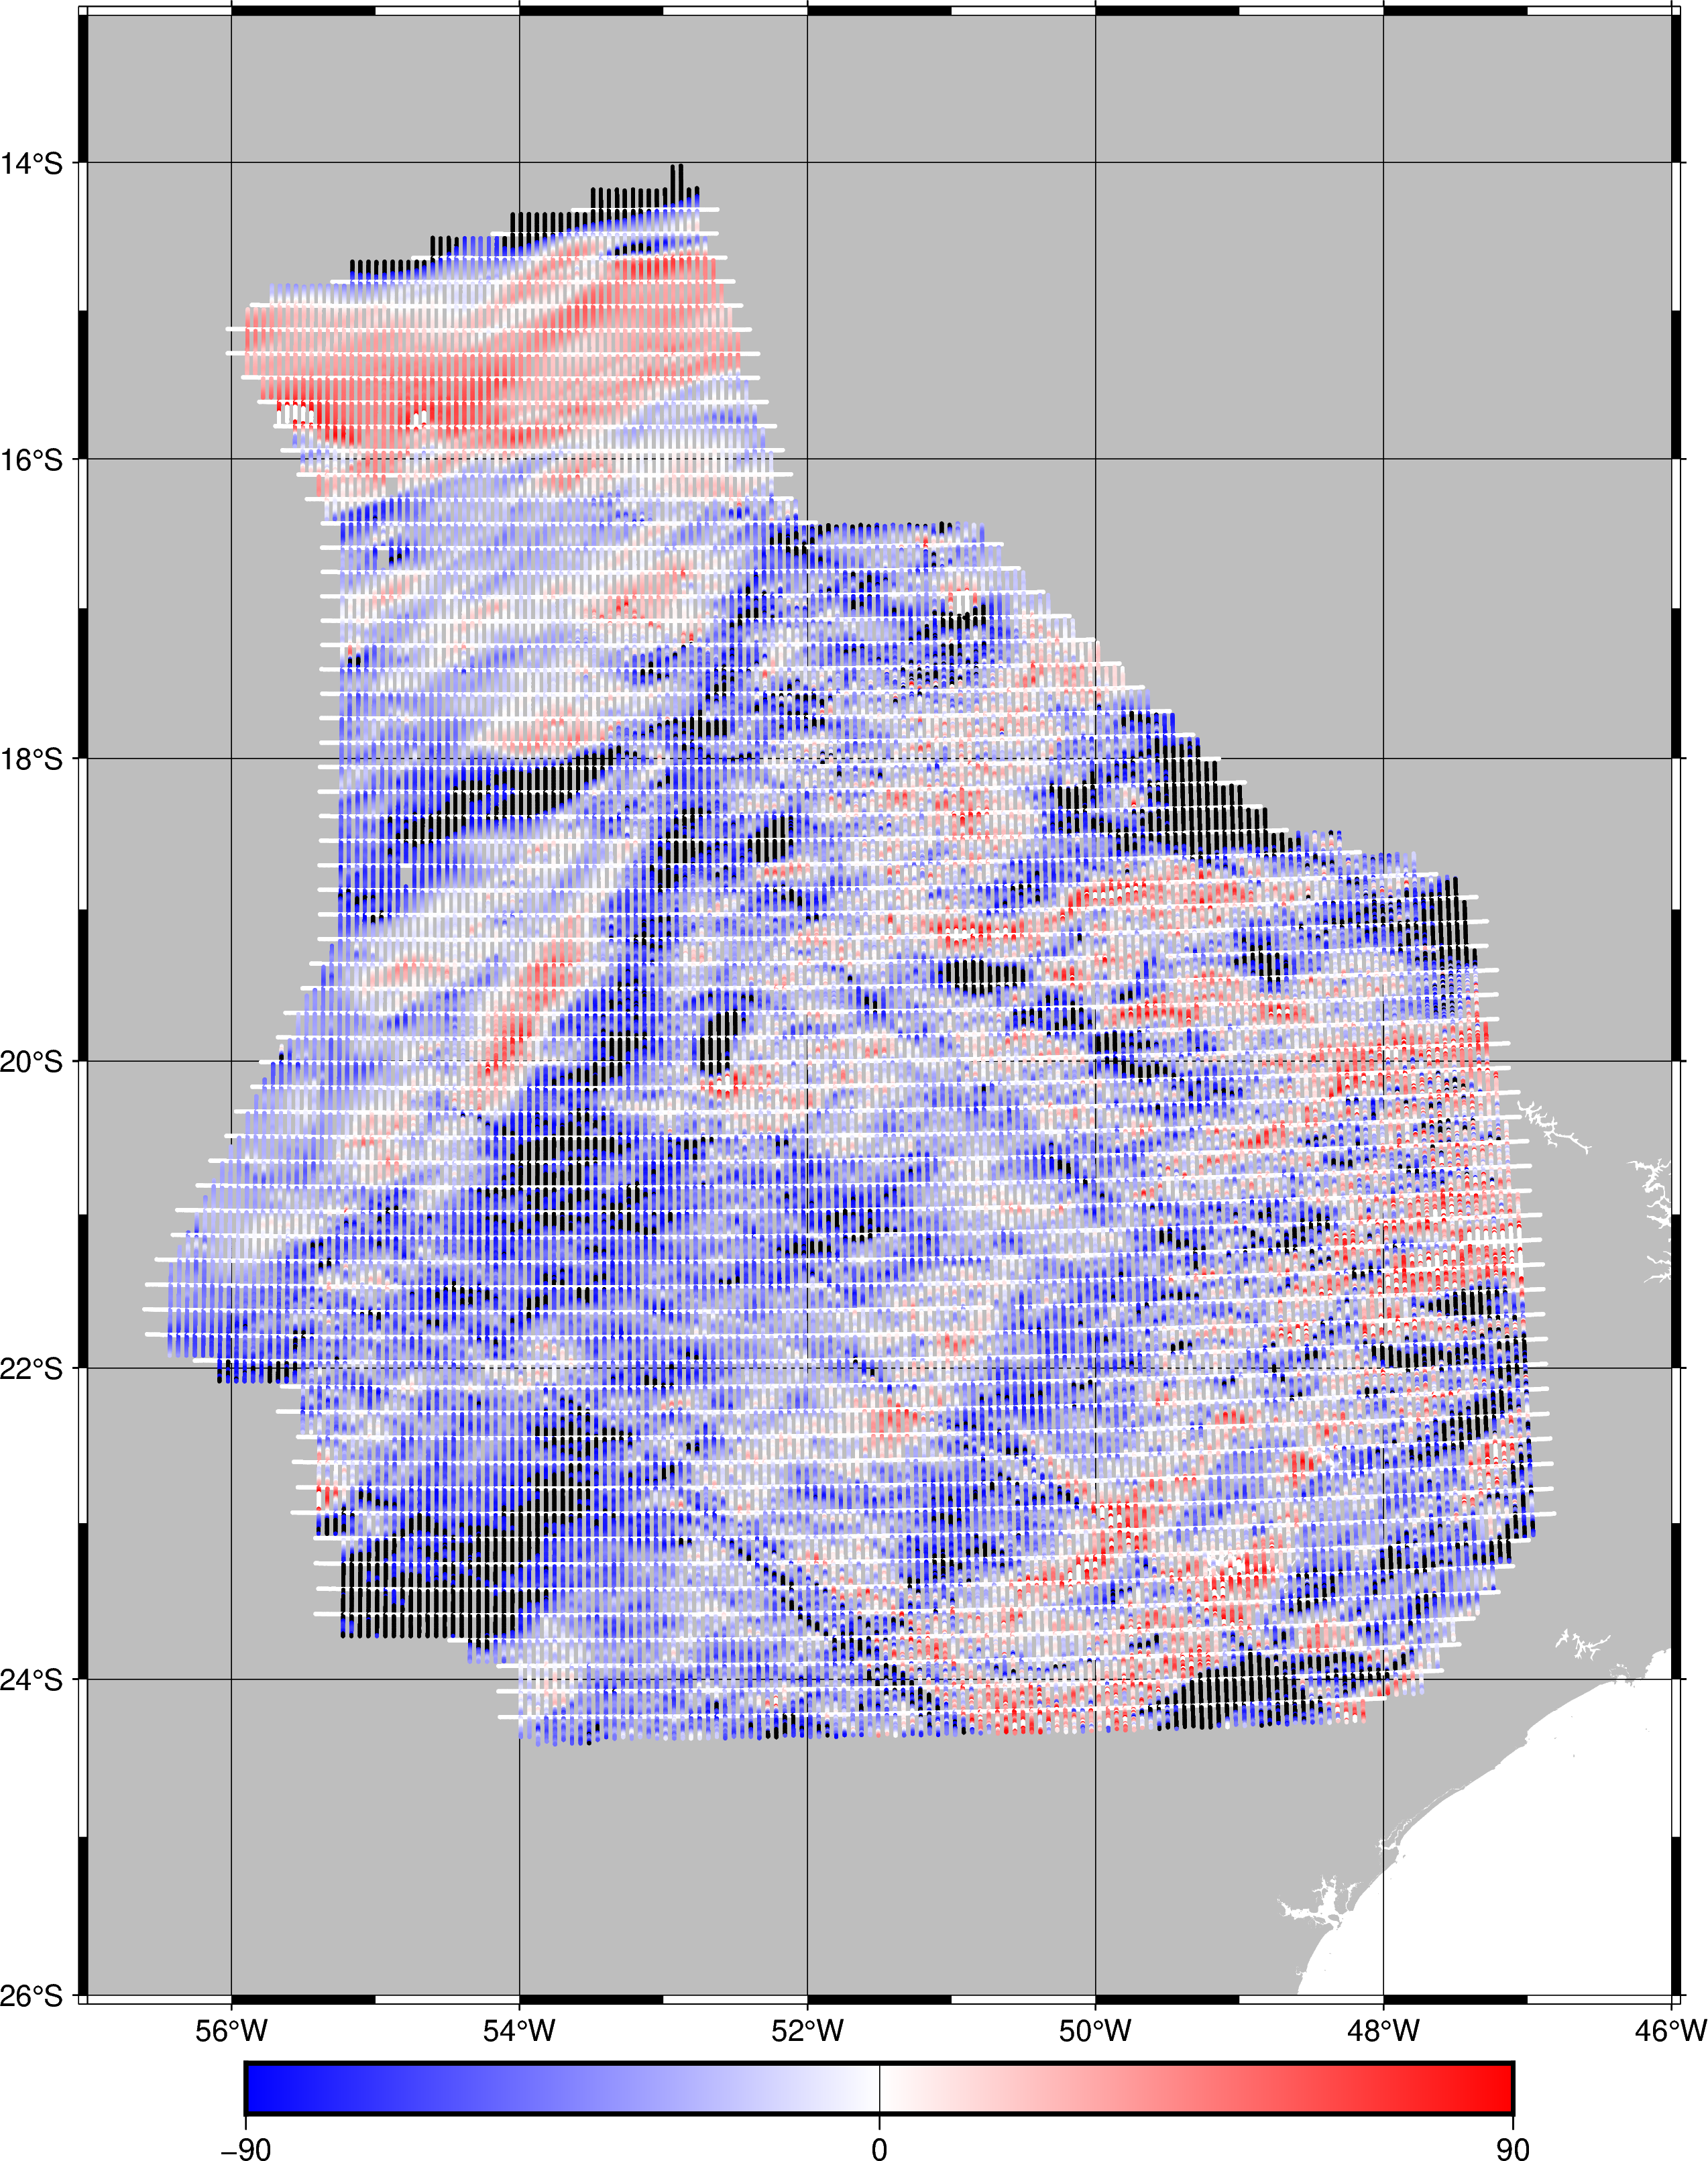

In [4]:
fig = pygmt.Figure()

fig.coast(
    region=[-57, -46, -26, -13],
    projection="M20c", 
    frame="afg",
    land="gray"
)

scale = np.nanpercentile(df.mag, 90)
scale = 90
pygmt.makecpt(cmap="polar+h", series=[-scale, scale])

fig.plot(
    x=df.long,
    y=df.lat,
    fill=df.mag,
    style="c0.05c",
    cmap=True
)

fig.colorbar(position="JBC")
fig.show(width=1000)

In [5]:
lon = df["long"].values
lat = df["lat"].values
height = df["height"].values


ellipsoid = bl.WGS84
radius = ellipsoid.mean_radius 


coordinates = (lon, lat, height+radius)

inclination, declination = 30, 20  
noise_level = 0.02

#Source 1 
source1a = sph.profile_points((-56,-16),(-52,-15), 1000, ellipsoid.mean_radius - 4e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, 5e8), np.full(1000, 45),np.full(1000, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source1a, magnetic_moment)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)

source1b = sph.profile_points((-56,-15),(-54,-16), 1000, ellipsoid.mean_radius - 4e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, 5e8), np.full(1000, 45),np.full(1000, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source1b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source1c = sph.profile_points((-54.5,-16),(-53,-14.7), 1000, ellipsoid.mean_radius - 4e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, 5e8), np.full(1000, 45),np.full(1000, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source1c, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 2 
source2a= sph.profile_points((-52,-16),(-53,-16), 300, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(300, 3e8), np.full(300, 48),np.full(300, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source2a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source2b= sph.profile_points((-54,-16.7),(-53,-16.7), 300, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(300, 3e8), np.full(300, 48),np.full(300, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source2b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 3
source3= sph.profile_points((-54,-17.5),(-54.5,-17.5), 150, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(150, 3e8), np.full(150, 48),np.full(150, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source3, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 4
source4a= sph.profile_points((-54,-20),(-53.5,-19), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source4a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source4b= sph.profile_points((-54.5,-19.5),(-54,-18.5), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source4b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source4c= sph.profile_points((-54.6,-20.4),(-54.6,-20.4), 100, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(100, 3e8), np.full(100, 48),np.full(100, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source4c, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 5
source5a= sph.profile_points((-52,-19),(-49,-19), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source5a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5b= sph.profile_points((-50,-19.6),(-48,-19.6), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source5b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5c= sph.profile_points((-48,-20),(-47,-20), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source5c, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5d= sph.profile_points((-48,-20.4),(-47,-20.4), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source5d, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5e= sph.profile_points((-48,-20.9),(-47,-20.9), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source5e, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5f= sph.profile_points((-50,-17),(-52,-18.9), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source5f, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)


#Substituir por um dipolo
source5g= sph.profile_points((-52.3,-19.6),(-52.3,-19.6), 100, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(100, 3e8), np.full(100, 48),np.full(100, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source5g, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 6
source6a= sph.profile_points((-48,-20.9),(-51,-23.9), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source6a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source6b= sph.profile_points((-47,-20.9),(-50,-24.9), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source6b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source6c= sph.profile_points((-51.4,-22),(-50.2,-21), 250, ellipsoid.mean_radius - 3e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source6c, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 7
source7a= sph.profile_points((-52,-16),(-53.8,-21), 250, ellipsoid.mean_radius - 2e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, -3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source7a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 8 
source8a= sph.profile_points((-55,-23.5),(-54,-23.1), 400, ellipsoid.mean_radius - 5e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(400, -7e8), np.full(400, 48),np.full(400, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source8a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 9
source9a= sph.profile_points((-51,-24.2),(-54,-22), 250, ellipsoid.mean_radius - 2e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, -3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source9a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source9b= sph.profile_points((-48,-24.2),(-51.5,-21.2), 250, ellipsoid.mean_radius - 2e4)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, -3e8), np.full(250, 48),np.full(250, 20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, source9b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Regional Field
regional = vd.grid_coordinates([-57, -46, -26, -13], spacing=0.1, extra_coords=ellipsoid.mean_radius-30e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(regional[0].size, -1e10), np.full(regional[0].size, -20),np.full(regional[0].size, -20))
magnetic_field = sph.dipole_magnetic_spherical(coordinates, regional, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Random noise
magnetic_anomaly += np.random.default_rng(42).normal(
    0, noise_level, size=magnetic_anomaly.shape
)

# # Syntetic dipoles
# n_dipoles = 150
# dipoles = tuple(c.ravel() for c in vd.scatter_points(region= (-57, -46, -26, -13), size= n_dipoles, extra_coords= ellipsoid.mean_radius - 4e3))

# magnetic_field = sph.dipole_magnetic_spherical(coordinates,dipoles,magnetic_moments = hm.magnetic_angles_to_vec(
#     np.full(n_dipoles, 1e12), np.full(n_dipoles, inclination), np.full(n_dipoles, declination)   
# ))
# magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

(np.float64(-57.095173493),
 np.float64(-46.323635067),
 np.float64(-24.936586695),
 np.float64(-13.501575415000001))

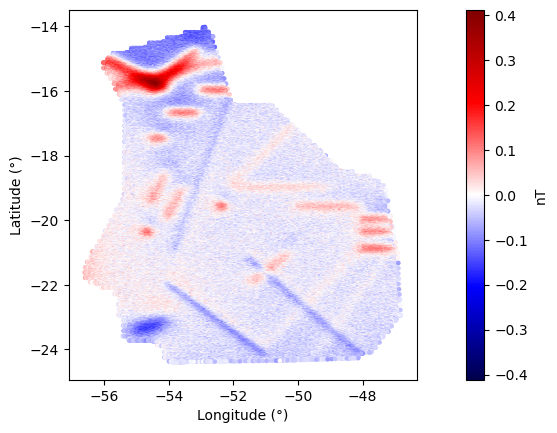

In [6]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

In [7]:
equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 2e4
)



damping = 1e-10
eqs_inc = 90
eqs_dec = 0
eqs_dipole_unit = hm.magnetic_angles_to_vec(1,eqs_inc, eqs_dec)

In [8]:
window_size = 2
_, source_indices = vd.rolling_window(equivalent_layer, size=window_size, spacing=window_size / 2)
_, data_indices = vd.rolling_window(coordinates, size=window_size, spacing=window_size / 2)
source_indices = [i[0] for i in source_indices.ravel()]
data_indices = [i[0] for i in data_indices.ravel()]

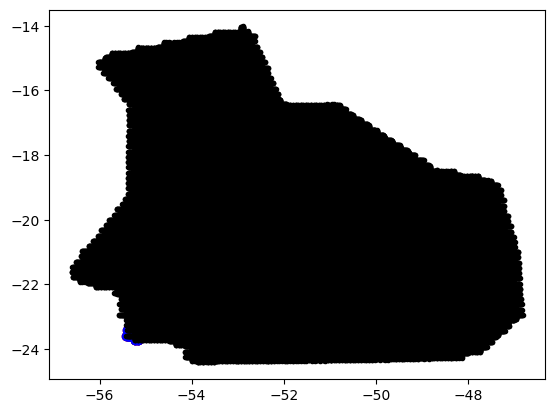

In [9]:
i = 1

data_coord = tuple(c[data_indices[i]] for c in coordinates)
source_coord = tuple(c[source_indices[i]] for c in equivalent_layer)

plt.plot(*data_coord[:2], "or")
plt.plot(*source_coord[:2], "ob")
plt.plot(*coordinates[:2], ".k")

In [10]:
def compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, moment_amplitudes):
    
    moments = [
        hm.magnetic_angles_to_vec(amplitude, inclination, declination)
        for amplitude in moment_amplitudes
    ]

    grided_magnetic_anomaly = np.zeros(grid_coord[0].shape)


    dipole_latitudes, dipole_longitudes, dipole_radii = dipole_data

    for lat, lon, r, moment in zip(dipole_latitudes.flatten(), dipole_longitudes.flatten(), dipole_radii.flatten(), moments):
        dipole_coordinates = np.array([lat, lon, r])
        
        magnetic_field = sph.dipole_magnetic_spherical(
            grid_coord,
            dipoles=dipole_coordinates,
            magnetic_moments=moment
        )
        
        grided_magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

    return grided_magnetic_anomaly

In [11]:
grid_coord = tuple(c.ravel() for c in vd.grid_coordinates((-57, -46, -26, -13), shape=(150, 150), extra_coords=ellipsoid.mean_radius + 200))



# Source 1
grided_dd_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, source1a, np.full(1000, 5e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source1b, np.full(1000, 5e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source1c, np.full(1000, 5e8))

# Source 2
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source2a, np.full(300, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source2b, np.full(300, 3e8))

# Source 3
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source3, np.full(150, 3e8))

# Source 4
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source4a, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source4b, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source4c, np.full(100, 3e8))

# Source 5
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5a, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5b, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5c, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5d, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5e, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5f, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5g, np.full(100, 3e8))

# Source 6
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source6a, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source6b, np.full(250, 3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source6c, np.full(250, 3e8))

# Source 7
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source7a, np.full(250, -3e8))

# Source 8
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source8a, np.full(400, -7e8))

# Source 9
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source9a, np.full(250, -3e8))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source9b, np.full(250, -3e8))

# Campo regional
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, regional, np.full(regional[0].size, -1e10))

# Ruído aleatório
grided_dd_anomaly += np.random.default_rng(42).normal(0, noise_level, size=grided_dd_anomaly.shape)


In [12]:
def fit(coordinates, data, eqs_source_coords, damping, eqs_inc, eqs_dec, inclination_main_field, declination_main_field):
    A = sph.jacobian(
        coordinates, 
        eqs_source_coords,
        eqs_inc, eqs_dec,
        inclination_main_field, declination_main_field
    )
    eqs_dipole_moment_amplitude = sph.calculate_coefficients(
        data, A, damping=damping,
    )
    return eqs_dipole_moment_amplitude

In [13]:
rmses = []
residuals = magnetic_anomaly.copy()
scale = vd.maxabs(magnetic_anomaly)
dipole_moment_amp = np.zeros_like(equivalent_layer[0])

predicted_total_field_grid = grided_dd_anomaly.copy()

window_indices = list(range(len(data_indices)))
np.random.shuffle(window_indices)
for i in window_indices:
    data_coord = tuple(c[data_indices[i]] for c in coordinates)
    source_coord = tuple(c[source_indices[i]] for c in equivalent_layer)
    
    eqs_dipole_moment_amp = fit(
        data_coord,
        residuals[data_indices[i]],
        source_coord,
        damping,
        eqs_inc,
        eqs_dec,
        inclination,
        declination
    )
    dipole_moment_amp[source_indices[i]] += eqs_dipole_moment_amp
    eqs_dipole_moment =  np.array( hm.magnetic_angles_to_vec(
    np.full(eqs_dipole_moment_amp.size, 1),  
    np.full(eqs_dipole_moment_amp.size, inclination),  
    np.full(eqs_dipole_moment_amp.size, declination)   
))


    predicted_total_field_anomaly = hm.total_field_anomaly(
        sph.dipole_magnetic_spherical(coordinates, source_coord, eqs_dipole_moment),
          inclination, declination)
    residuals -= predicted_total_field_anomaly
    
    
    predicted_total_field_grid -= hm.total_field_anomaly(
        sph.dipole_magnetic_spherical(grid_coord, source_coord, eqs_dipole_moment),
        inclination, declination,
    )

In [ ]:
plt.figure(figsize=(20,4))
plt.subplot(1,3,2)
plt.title("Observed Total Field Anomaly")
plt.scatter(
    *grid_coord[:2], c=grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')
plt.subplot(1,3,1)
plt.title("Predicted Total Field Anomaly")
plt.scatter(
    *grid_coord[:2], c=predicted_total_field_grid, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')
diff_grid_tfa = grided_dd_anomaly - predicted_total_field_grid
rmse_grid_tfa = np.sqrt(np.square(diff_grid_tfa).mean())
plt.subplot(1,3,3)
plt.title('Residuals')
plt.scatter(
    *grid_coord[:2], c=diff_grid_tfa, cmap="seismic")
plt.colorbar(label='nT')
plt.tight_layout()